In [17]:
import pandas as pd 
import numpy as np
from CBFV import composition
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import torch
from umap import UMAP
from matplotlib import pyplot as plt

In [5]:
def fourier_features(T, n_freqs=6):
    """
    Generate Fourier features for temperature values.
    
    Args:
        T: 1D tensor of temperature values (shape: [N])
        n_freqs: number of frequency components (produces 2*n_freqs features)
    
    Returns:
        2D tensor of shape [N, 2*n_freqs] where each row is the Fourier encoding
    """
    # Ensure T is 2D with shape [N, 1] for broadcasting
    if T.dim() == 1:
        T = T.unsqueeze(1)
    
    feats = []
    for k in range(n_freqs):
        freq = 2**k
        feats.append(torch.sin(2 * torch.pi * freq * T))
        feats.append(torch.cos(2 * torch.pi * freq * T))
    
    # Stack along dim=1 to get shape [N, 2*n_freqs]
    return torch.cat(feats, dim=1)

In [6]:
calphed_data = pd.read_csv(r'Data/calphad_alloys_train_opt_reshaped.csv')

In [7]:
calphed_data.head()

,alloy_string,temperature,DF_AG2CA,DF_AG3BE8,DF_AG3CA5,DF_AG3MG,DF_AG7CA2,DF_AG9CA2,DF_AGCA,DF_AGCA3,...,NF_YSI2_H,NF_YSI2_R,NF_ZINCBLENDE_B3,NF_ZR2SI,NF_ZR3SI,NF_ZR3SI2,NF_ZR5SI3,NF_ZR5SI4,NF_ZRSI,NF_ZRSI2
0,B22.00Co4.00Fe68.00Y6.00,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,B22.00Co4.00Fe68.00Y6.00,50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,B22.00Co4.00Fe68.00Y6.00,100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,B22.00Co4.00Fe68.00Y6.00,150,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,B22.00Co4.00Fe68.00Y6.00,200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:

# Create separate y dataframes for NF (phase fractions) and DF (driving forces)
all_cols = calphed_data.drop(columns=['alloy_string', 'temperature']).columns.tolist()

# Split into NF and DF columns
nf_cols = [col for col in all_cols if col.startswith('NF_')]
df_cols = [col for col in all_cols if col.startswith('DF_')]

y_nf = calphed_data[nf_cols]
y_df = calphed_data[df_cols]

print(f"Phase Fractions (NF) shape: {y_nf.shape}")
print(f"Driving Forces (DF) shape: {y_df.shape}")
print(f"\nNF columns: {len(nf_cols)}, DF columns: {len(df_cols)}")
y_nf.head()

Phase Fractions (NF) shape: (44982, 804)
Driving Forces (DF) shape: (44982, 804)

NF columns: 804, DF columns: 804


,NF_AG2CA,NF_AG3BE8,NF_AG3CA5,NF_AG3MG,NF_AG7CA2,NF_AG9CA2,NF_AGCA,NF_AGCA3,NF_AGCD_ETA,NF_AGIN2,...,NF_YSI2_H,NF_YSI2_R,NF_ZINCBLENDE_B3,NF_ZR2SI,NF_ZR3SI,NF_ZR3SI2,NF_ZR5SI3,NF_ZR5SI4,NF_ZRSI,NF_ZRSI2
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:

# Overall stats for all non-zero values in y_nf
nf_all_nonzero = y_nf.values.flatten()
nf_all_nonzero = nf_all_nonzero[nf_all_nonzero != 0]

print(f"Total elements: {y_nf.size}")
print(f"Non-zero elements: {len(nf_all_nonzero)} ({len(nf_all_nonzero)/y_nf.size*100:.2f}%)")
print(f"Zero elements: {y_nf.size - len(nf_all_nonzero)} ({(y_nf.size - len(nf_all_nonzero))/y_nf.size*100:.2f}%)")
print(f"\n--- Non-zero value stats ---")
print(f"Min:    {nf_all_nonzero.min():.6f}")
print(f"Max:    {nf_all_nonzero.max():.6f}")
print(f"Mean:   {nf_all_nonzero.mean():.6f}")
print(f"Std:    {nf_all_nonzero.std():.6f}")
print(f"Median: {np.median(nf_all_nonzero):.6f}")


Total elements: 36165528
Non-zero elements: 78522 (0.22%)
Zero elements: 36087006 (99.78%)

--- Non-zero value stats ---
Min:    0.000000
Max:    1.000000
Mean:   0.533035
Std:    0.397935
Median: 0.449720


In [10]:

# Overall stats for all non-zero values in y_df
df_all_nonzero = y_df.values.flatten()
df_all_nonzero = df_all_nonzero[df_all_nonzero != 0]

print(f"Total elements: {y_df.size}")
print(f"Non-zero elements: {len(df_all_nonzero)} ({len(df_all_nonzero)/y_df.size*100:.2f}%)")
print(f"Zero elements: {y_df.size - len(df_all_nonzero)} ({(y_df.size - len(df_all_nonzero))/y_df.size*100:.2f}%)")
print(f"\n--- Non-zero value stats ---")
print(f"Min:    {df_all_nonzero.min():.6f}")
print(f"Max:    {df_all_nonzero.max():.6f}")
print(f"Mean:   {df_all_nonzero.mean():.6f}")
print(f"Std:    {df_all_nonzero.std():.6f}")
print(f"Median: {np.median(df_all_nonzero):.6f}")


Total elements: 36165528
Non-zero elements: 3012150 (8.33%)
Zero elements: 33153378 (91.67%)

--- Non-zero value stats ---
Min:    -358.040000
Max:    -0.000005
Mean:   -4.164577
Std:    5.784951
Median: -2.541700


In [11]:
# Extract alloy strings and create formula dataframe
formula_df = pd.DataFrame({'formula': calphed_data['alloy_string']})
print(f"Formula dataframe shape: {formula_df.shape}")
formula_df.head()

Formula dataframe shape: (44982, 1)


,formula
0,B22.00Co4.00Fe68.00Y6.00
1,B22.00Co4.00Fe68.00Y6.00
2,B22.00Co4.00Fe68.00Y6.00
3,B22.00Co4.00Fe68.00Y6.00
4,B22.00Co4.00Fe68.00Y6.00


In [12]:
# Generate Composition-Based Feature Vectors using CBFV
# CBFV expects 'formula' column and optionally a 'target' column
# Add a dummy target for featurization (we'll drop it after)
formula_df['target'] = 0

# Generate CBFVs using the magpie element property database
X, y, formulae, skipped = composition.generate_features(formula_df, elem_prop='magpie')
print(f"CBFV features shape: {X.shape}")
print(f"Number of skipped formulas: {len(skipped)}")
X.head()

Processing Input Data: 100%|██████████| 44982/44982 [00:01<00:00, 41443.11it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 44982/44982 [00:01<00:00, 36535.64it/s]


	Creating Pandas Objects...
CBFV features shape: (44982, 132)
Number of skipped formulas: 0


,avg_Number,avg_MendeleevNumber,avg_AtomicWeight,avg_MeltingT,avg_Column,avg_Row,avg_CovalentRadius,avg_Electronegativity,avg_NsValence,avg_NpValence,...,mode_NValence,mode_NsUnfilled,mode_NpUnfilled,mode_NdUnfilled,mode_NfUnfilled,mode_NUnfilled,mode_GSvolume_pa,mode_GSbandgap,mode_GSmagmom,mode_SpaceGroupNumber
0,22.2,56.28,48.044699,1926.7,8.84,3.62,124.68,1.8416,2.0,0.22,...,8.0,0.0,0.0,4.0,0.0,4.0,10.73,0.0,2.110663,229.0
1,22.2,56.28,48.044699,1926.7,8.84,3.62,124.68,1.8416,2.0,0.22,...,8.0,0.0,0.0,4.0,0.0,4.0,10.73,0.0,2.110663,229.0
2,22.2,56.28,48.044699,1926.7,8.84,3.62,124.68,1.8416,2.0,0.22,...,8.0,0.0,0.0,4.0,0.0,4.0,10.73,0.0,2.110663,229.0
3,22.2,56.28,48.044699,1926.7,8.84,3.62,124.68,1.8416,2.0,0.22,...,8.0,0.0,0.0,4.0,0.0,4.0,10.73,0.0,2.110663,229.0
4,22.2,56.28,48.044699,1926.7,8.84,3.62,124.68,1.8416,2.0,0.22,...,8.0,0.0,0.0,4.0,0.0,4.0,10.73,0.0,2.110663,229.0


In [13]:
fourier_Temp_features = fourier_features(torch.tensor(calphed_data['temperature'].values, dtype=torch.float32))
fourier_Temp_features_df = pd.DataFrame(
    fourier_Temp_features.numpy(),
    columns=[f'fourier_{i}' for i in range(fourier_Temp_features.shape[1])],
    index=calphed_data.index
)

X_combined = pd.concat([X, fourier_Temp_features_df], axis=1)


In [14]:
# Create 5 CV groups by clustering similar alloys together
# Standardize features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# Use KMeans to group similar alloys into 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cv_groups = kmeans.fit_predict(X_scaled)

#local CV, umap,

# Add group assignments to a dataframe for reference
cv_group_df = pd.DataFrame({
    'formula': formulae,
    'cv_group': cv_groups
})

print("CV Group distribution:")
print(cv_group_df['cv_group'].value_counts().sort_index())
print(f"\nTotal samples: {len(cv_groups)}")
cv_group_df.head(10)

CV Group distribution:
cv_group
0     7599
1    16014
2     6375
3    10200
4     4794
Name: count, dtype: int64

Total samples: 44982


,formula,cv_group
0,B22.00Co4.00Fe68.00Y6.00,3
1,B22.00Co4.00Fe68.00Y6.00,3
2,B22.00Co4.00Fe68.00Y6.00,3
3,B22.00Co4.00Fe68.00Y6.00,3
4,B22.00Co4.00Fe68.00Y6.00,3
5,B22.00Co4.00Fe68.00Y6.00,3
6,B22.00Co4.00Fe68.00Y6.00,3
7,B22.00Co4.00Fe68.00Y6.00,3
8,B22.00Co4.00Fe68.00Y6.00,3
9,B22.00Co4.00Fe68.00Y6.00,3


c:\Users\Chris\Gen_env_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


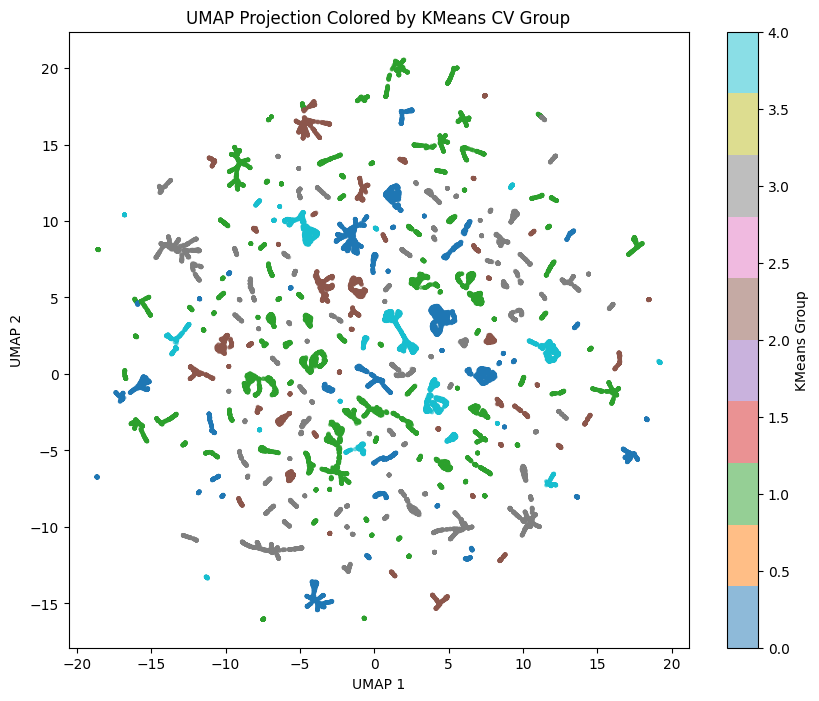

In [18]:


reducer = UMAP(n_components=2, random_state=42, n_neighbors=30)
embedding = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=cv_groups, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(scatter, label='KMeans Group')
plt.title('UMAP Projection Colored by KMeans CV Group')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()